In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, LSTM, Flatten

In [4]:
# 1. Load Dataset
df = pd.read_csv("/content/my_dataset_features.csv")
print(df.head())

       mfcc_0      mfcc_1     mfcc_2     mfcc_3     mfcc_4     mfcc_5  \
0 -180.261490  123.208557  12.179420  25.168259   1.716785   8.663729   
1 -226.138382   52.582932  -0.217220  18.274734 -12.700911 -10.182571   
2 -294.740601  118.139587   9.248292   6.061491  -0.304913 -13.041572   
3 -141.580521   82.594872  12.024048  37.845757   5.738265   4.515667   
4 -209.824310  126.672104  -6.879056  31.562664   3.401516  -5.088613   

      mfcc_6     mfcc_7     mfcc_8     mfcc_9    mfcc_10   mfcc_11    mfcc_12  \
0   7.846949  19.999519   4.124840   5.814000  -5.934352 -2.364329 -12.630212   
1 -25.913273 -14.967414 -28.487017 -17.641758 -18.253475 -1.197921  -7.264189   
2 -16.138256 -11.038885  -7.435064  -6.881006  -8.622358 -4.305947  -1.445444   
3   6.479244   8.703977 -11.235284  16.566845  -0.778718  7.354715   1.187736   
4  10.778674   0.985945   1.518578  -3.790230  -5.671856  6.887865   0.264488   

      centroid    bandwidth      rolloff       zcr         label  
0  1342

In [5]:
# 2. Separate Features & Labels
X = df.drop("label", axis=1).values   # "label" column contains genres
y = df["label"].values

In [6]:
# 3. Encode Labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)
genres = encoder.classes_
print("Classes:", genres)

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Classes: ['Rap song' 'melody songs']


In [7]:
# 5. Scale Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# 6. Reshape for CNN+LSTM
# Example: reshape into (timesteps, features_per_step)
# Here we make each sample (num_features, 1) like a sequence of features
X_train = np.expand_dims(X_train, axis=2)  # shape: (samples, features, 1)
X_test = np.expand_dims(X_test, axis=2)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (32, 17, 1)
X_test shape: (9, 17, 1)


In [9]:
# 7. Build CNN+LSTM Model
model = Sequential([
    Conv1D(64, 3, activation="relu", input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(2),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(len(genres), activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# 8. Train Model
history = model.fit(X_train, y_train, epochs=30, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.7052 - val_accuracy: 0.4444 - val_loss: 0.7029
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5312 - loss: 0.6964 - val_accuracy: 0.4444 - val_loss: 0.7038
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5312 - loss: 0.6848 - val_accuracy: 0.4444 - val_loss: 0.7061
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6562 - loss: 0.6809 - val_accuracy: 0.4444 - val_loss: 0.7097
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5938 - loss: 0.6766 - val_accuracy: 0.4444 - val_loss: 0.7148
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5625 - loss: 0.6669 - val_accuracy: 0.4444 - val_loss: 0.7205
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5625 - loss: 0.6587 - val_accuracy: 0.4444 - val_loss: 0.7284
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5625 - loss: 0.6418 - val_accuracy: 0.4444 - val_loss: 0.7375


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
              precision    recall  f1-score   support

    Rap song       1.00      0.20      0.33         5
melody songs       0.50      1.00      0.67         4

    accuracy                           0.56         9
   macro avg       0.75      0.60      0.50         9
weighted avg       0.78      0.56      0.48         9



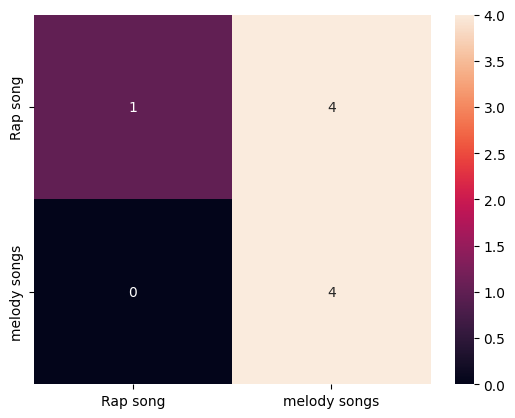

In [11]:
# 9. Evaluate
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=genres))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, xticklabels=genres, yticklabels=genres, fmt="d")
plt.show()

In [12]:
# 10. Predict on new sample
sample = X_test[0].reshape(1, X_test.shape[1], 1)
pred = np.argmax(model.predict(sample), axis=1)
print("Predicted:", genres[pred[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Predicted: Rap song
